4-Velocity magnitude is 0
4-Velcity is [1, 0, 0, 1]
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  -2.98023226097399e-8
4Velo mag is  0
4Velo mag is  0
4Velo mag is  2.98023226097399e-8
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0
4Velo mag is  0

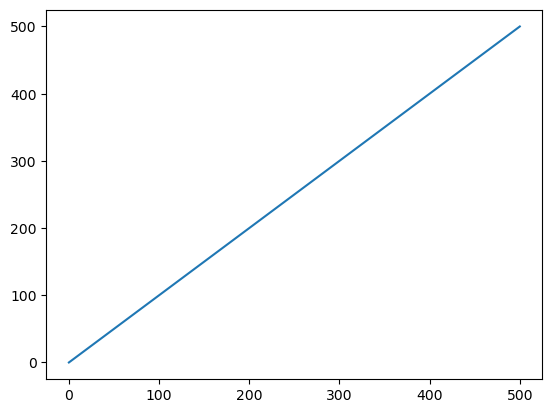

In [2]:
##### IMPORTS #####
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
##### END OF IMPORTS #####

##### USER INPUTS #####

#INPUT: Please define the symbols of your coordinate system here, make your timelike coordinate the FIRST symbol!
coords = sp.symbols('t r theta phi')

for c in coords: #DO NOT TOUCH THIS LOOP (this loop makes the coordinates symbols)
    globals()[str(c)] = c


#INPUT: Please input if this particle is massless or not
massless_particle = True


#INPUT: Please define your metric here, make each column refer to above symbols in the same order!
g = sp.Matrix(
    [[-1 , 0 , 0 , 0] ,
     [0 , 1 , 0 , 0 ],
     [0 , 0 , 1 , 0 ],
     [0 , 0 , 0 , 1]]
)


# g = sp.Matrix(
#     [[-(1 - (10 / r)) , 0 , 0 , 0] ,                #TIMELIKE COLUMN
#      [0 , 1/(1 - (10 / r)) , 0 , 0] ,               #SPACELIKE COLUMN
#      [0 , 0 , r**2 , 0] ,                           #SPACELIKE COLUMN
#      [0 , 0 , 0 , r**2 * sp.sin(theta)**2]]         #SPACELIKE COLUMN
# )


#INPUT: Please input if this metric should be physically viable.
physically_viable = True


#INPUT: Please input your initial 4-position, make each entry refer to coordinates in same order as above!
ri = [0 , 16 , np.pi/2 , 0]


#INPUT: Please input your initial 3-velocity (ie the spatial velocities, not the timelike one), follow same spatial order as above
vi = [0 , 0 , 1]


#INPUT: Please input the amount of "integration time" you would like this simulation to go by and the step amount
lamTot = 500 #Total sim code time

##### END OF USER INPUTS #####


##### FUNCTIONS #####

#This function will calculate the inverse metric and corresponding Christoffel symbols
def calcChristoffel(g , indices , coords):

    #This program will calculate the connection coefficients for g using the Levi-Civita connection

    #Find g inverse
    ginv = g.inv()

    #Initialize the connections as a 4x4x4 array
    christoffel = sp.MutableDenseNDimArray.zeros(4,4,4)

    #The Levi-Civita Connection is
    #Γ^m_np = .5 * g^ms ( deriv_p(g_sn) + deriv_n(g_sp) - deriv_s(g_np) )
    for mu in range(0 , 4):
        for nu in range(0 , 4):
            for rho in range(0 , 4):
                expr = 0
                for sigma in range(0 , 4):
                    expr += .5 * ginv[mu , sigma] * (
                        sp.diff(g[sigma , nu] , indices[rho]) +
                        sp.diff(g[sigma , rho] , indices[nu]) -
                        sp.diff(g[nu , rho] , indices[sigma])
                    )

                christoffel[mu , nu , rho] = expr

    #We have the christoffels yay
    #Now lets convert them into functions yaya
    Gamma_Function = [[[
        sp.lambdify(coords, christoffel[mu,nu,rho], "numpy") for rho in range(4)]
            for nu in range(4)]
            for mu in range(4)]


    return (Gamma_Function , ginv) #Return ginv also just incase its useful elsewhere

#This function will calculate the
def findUt(is_null , r , v , g , indices):

    #For our integration to be correct, we need to find the t-component of the initial four velocity.
    #This ut determines the evolution of the system as a massive or massless particle.
    #Per the diff geo, the magnitude of the four velo is found via u^m*u^n*g_mn
    #This magnitude must equal -1 for a massive particle and 0 for a massless particle

    if is_null:
        condition = 0

    else:
        condition = -1

    #Lets sub in the initial position symbols into the metric
    subs_dict = {
        indices[0] : r[0] ,
        indices[1] : r[1] ,
        indices[2] : r[2] ,
        indices[3] : r[3] ,
    }

    numeric_g = g.subs(subs_dict)

    #Lets initialize our unknown ut
    ut = sp.symbols("ut" , positive = True)
    u = [ut , v[0] , v[1] , v[2]]

    #Now we do the inner product correctly
    expr = 0
    for m in range(0 , 4):
        for n in range(0 , 4):
            expr += u[m] * u[n] * numeric_g[m , n]

    #Make the expression an equation using condition
    inner_product_constraint = sp.Eq(expr , condition)

    #Solve for ut
    time_part = sp.solve(inner_product_constraint , ut)

    #Check if a solution was found; if not indicate signularity failure
    if len(time_part) == 0:
        print("Error")
        return np.nan

    #Put the four velocity together
    u = [time_part[0] , vi[0] , vi[1] , vi[2]]

    #Ensure correct magnitude
    expr = 0
    for mu in range(0 , 4):
        for nu in range(0 , 4):
            expr += u[mu] * u[nu] * numeric_g[mu , nu]

    print(f"4-Velocity magnitude is {expr}")
    print(f"4-Velcity is {u}")
    return(u[0])

#This function will veify if the given metric is allowed
def verifyMetric(g , ri):

    #A valid spacetime metric is
    #1. A 4x4 matrix
    #2. Symmetric and real
    #3. Has a non-zero determinant
    #4. Has a Lorentzian signature (ie 1 negative eigenvalue and 3 positive eigenvalues since we are using (-,+,+,+))

    #Is this metric symmetric?
    if (not g.is_symmetric()):
        print("Error, this metric is not symmetric. Defaulting to Minkowski spacetime!!!")
        return -1
    assert g.is_symmetric() , "Error, this metric is not symmetric!"

    #Is this metric nonsingular?
    det = g.det()
    assert det != 0 , "Error, this metric is singular!"

    ###Does this metric have the correct (-,+,+,+) signature?
    check_negative = False

    #Lets sub in the initial position symbols into the metric
    subs_dict = {
        indices[0] : ri[0] ,
        indices[1] : ri[1] ,
        indices[2] : ri[2] ,
        indices[3] : ri[3] ,
    }

    g_initial = g.subs(subs_dict)
    eigs = g_initial.eigenvals()

    for (key,value) in eigs.items():

        if key < 0:
            if value == 1:
                check_negative = True

    assert check_negative , "Error, this metric does not have the correct Lorentzian signature (-,+,+,+)!"

#This function will form the geodesic equation
#make it 2 for loops through the implied summations (from 0 to 3) of the geodesic equations, add to an expression variable and return
def integrateGeodesics(g , christoffels , indices , cur_pos , cur_vel , is_null , runtime):
    #We will evolve the spatial coordinates and use the time coordinate as a constraint to ensure normalization does not skew due to rounding/numerical error

    #Define the state vector
    initial_state = [cur_pos[0] , #timelike coord
                     cur_pos[1] , #spacelike coord 1
                     cur_pos[2] , #spacelike coord 2
                     cur_pos[3] , #spacelike coord 3
                     cur_vel[0] , #timelike velo
                     cur_vel[1] , #spacelike velo 1
                     cur_vel[2] , #spacelike velo 2
                     cur_vel[3]   #spacelike velo 3
                    ]


    #Define the derivative operation
    def change_of_state(lam , state):

        #State vector is organized as
        # [timelike pos, spacelike pos1, spacelike pos2, spacelike pos3, spacelike velo1, spacelike velo2, spacelike velo3]


        #Sub in values
        subs_dict = {
            indices[0] : state[0] ,
            indices[1] : state[1] ,
            indices[2] : state[2] ,
            indices[3] : state[3] ,
        }


        numeric_christos = np.zeros((4 , 4 , 4))
        for mu in range(0 , 4):
            for nu in range(0 , 4):
                for rho in range(0 , 4):
                    numeric_christos[mu , nu , rho] = christoffels[mu][nu][rho](state[0] , state[1] , state[2] , state[3])

        #Unpack state for organization
        pos = [state[0] , state[1] , state[2] , state[3]]
        u = [state[4] , state[5] , state[6] , state[7]]

        numeric_g = g.subs(subs_dict)
        expr = 0
        for a in range(0,4):
            for b in range(0,4):
                expr += numeric_g[a,b] * u[a] * u[b]
        print("4Velo mag is " , expr)

        #Now we construct the "acceleration" components of the state change using the geodesic eq ye
        accel_list = []
        for k in range(0 , 4):
            accel = 0
            for mu in range(0 , 4):
                for nu in range(0 , 4):
                    accel += -1 * numeric_christos[k , mu , nu] * u[mu] * u[nu]
            accel_list.append(accel)

        #Return the change in state vector
        return [u[0] , u[1] , u[2] , u[3] , accel_list[0] , accel_list[1] , accel_list[2] , accel_list[3]]




    #Run the rk4 integrator
    sol = solve_ivp(
        fun = change_of_state ,
        t_span = (0 , runtime) ,
        y0 = initial_state ,
        method = 'Radau' ,
        max_step = 1
    )

    #save the array to practice on with other files
    np.savez(                                       #creates a fule that saves arrays
    "geodesic_output.npz",                          
    t=sol.t,
    y=sol.y,
    coords=[str(c) for c in coords]               #convert cooridnates from symbols to strngs so python doesnt yell
)

    #Return the solution
    return sol




#This function will integrate the geodesic equation
#rk4

#This function will make 6 parametric plots

##### END OF FUNCTIONS #####



##### RUN SIM #####

#Must check if metric is 4x4 and there are four coordinates
assert len(coords) == 4 , "Error, not enough/too many coordinates!"
assert g.shape == (4,4) , "Error, metric is not 4x4!"

#Create an indices dictionary
indices = {i: coords[i] for i in range(4)}
#print(f"Indices: {indices}")

#If physically viable metrics are set, check if this metric works
if physically_viable:
    verifyMetric(g = g , ri = ri)

#Calculate inverse metric and christoffel symbols
(Connections , ginv) = calcChristoffel(g = g , indices = indices , coords = coords)
#print(f"Connections: {Connections}")

#Find intial ut by using normalization condtion
ut_init = findUt(is_null = massless_particle , r = ri , v = vi , g = g , indices = indices)
ui = [ut_init , vi[0] , vi[1] , vi[2]]

#Integrate the geodesic equations
sol = integrateGeodesics(g = g , christoffels = Connections , indices = indices , cur_pos = ri , cur_vel = ui , is_null = massless_particle , runtime = lamTot)


#PLOTTING SECTION
print(sol.t)
print(sol.y[1])
print(sol.message)
print(sol.status)
#
#plt.plot(sol.t , sol.y[0] , color = "white")
# plt.plot(sol.t, sol.y[1] , color = "red")
# plt.plot(sol.t, sol.y[2] , color = "blue")
# phi_vals = np.array(sol.y[3], dtype=float)
# plt.plot(sol.t, np.sin(phi_vals), color="green")
plt.plot(sol.y[3] , sol.y[0])


